In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
IMAGE_DIR = DATA_DIR / "images"
METADATA_PATH = DATA_DIR / "HAM10000_metadata"

print("Project root:", PROJECT_ROOT)
print("Image directory:", IMAGE_DIR)
print("Metadata:", METADATA_PATH)

Project root: E:\Project\Saksham\skin-cancer-detection
Image directory: E:\Project\Saksham\skin-cancer-detection\data\raw\images
Metadata: E:\Project\Saksham\skin-cancer-detection\data\raw\HAM10000_metadata


In [3]:
df = pd.read_csv(METADATA_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 10015
Columns: 8


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [4]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

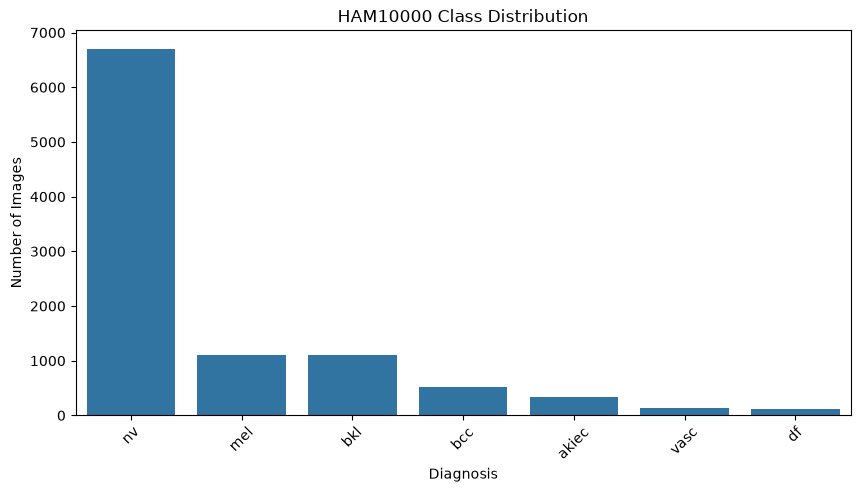

In [5]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="dx",
    order=df["dx"].value_counts().index
)

plt.title("HAM10000 Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

In [6]:
label_names = {
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "bkl": "Benign keratinocytic lesions",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratoses / intraepithelial carcinoma",
    "vasc": "Vascular lesions",
    "df": "Dermatofibroma"
}

df["diagnosis_name"] = df["dx"].map(label_names)

df[["dx", "diagnosis_name"]].drop_duplicates().sort_values("dx")

,dx,diagnosis_name
9687,akiec,Actinic keratoses / intraepithelial carcinoma
2462,bcc,Basal cell carcinoma
0,bkl,Benign keratinocytic lesions
1095,df,Dermatofibroma
1211,mel,Melanoma
64,nv,Melanocytic nevi
2320,vasc,Vascular lesions


In [7]:
df.isnull().sum()

lesion_id          0
image_id           0
dx                 0
dx_type            0
age               57
sex                0
localization       0
dataset            0
diagnosis_name     0
dtype: int64

In [8]:
df["age"].describe()

count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64

In [9]:
df["sex"].value_counts()

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

In [10]:
df["localization"].value_counts()

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

In [11]:
df[df["sex"] == "unknown"][["age", "sex", "localization"]].head(10)

,age,sex,localization
968,NaN,unknown,unknown
969,NaN,unknown,unknown
970,NaN,unknown,unknown
971,NaN,unknown,unknown
972,NaN,unknown,unknown
973,NaN,unknown,unknown
974,NaN,unknown,unknown
975,NaN,unknown,unknown
977,NaN,unknown,unknown
978,NaN,unknown,unknown


In [12]:
df[df["age"].isna()][["age", "sex", "localization"]].head(10)

,age,sex,localization
968,NaN,unknown,unknown
969,NaN,unknown,unknown
970,NaN,unknown,unknown
971,NaN,unknown,unknown
972,NaN,unknown,unknown
973,NaN,unknown,unknown
974,NaN,unknown,unknown
975,NaN,unknown,unknown
977,NaN,unknown,unknown
978,NaN,unknown,unknown


In [13]:
missing_age = df[df["age"].isna()]

print("Missing age:", len(missing_age))
print("Unknown sex:", (df["sex"] == "unknown").sum())
print("Missing-age records with unknown sex:",
      (missing_age["sex"] == "unknown").sum())

Missing age: 57
Unknown sex: 57
Missing-age records with unknown sex: 47


In [14]:
df[df["age"] == 0].shape[0]


39

Image ID: ISIC_0024349
Diagnosis: nv
Image path: E:\Project\Saksham\skin-cancer-detection\data\raw\images\ISIC_0024349.jpg
Image size: (600, 450)
Image mode: RGB


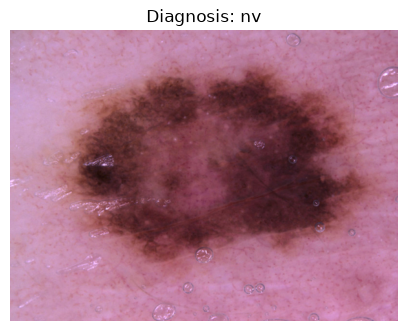

In [15]:
from PIL import Image
import random

# Pick one random record
sample = df.sample(1).iloc[0]

image_id = sample["image_id"]
diagnosis = sample["dx"]
image_path = IMAGE_DIR / f"{image_id}.jpg"

print("Image ID:", image_id)
print("Diagnosis:", diagnosis)
print("Image path:", image_path)

img = Image.open(image_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Diagnosis: {diagnosis}")
plt.axis("off")
plt.show()

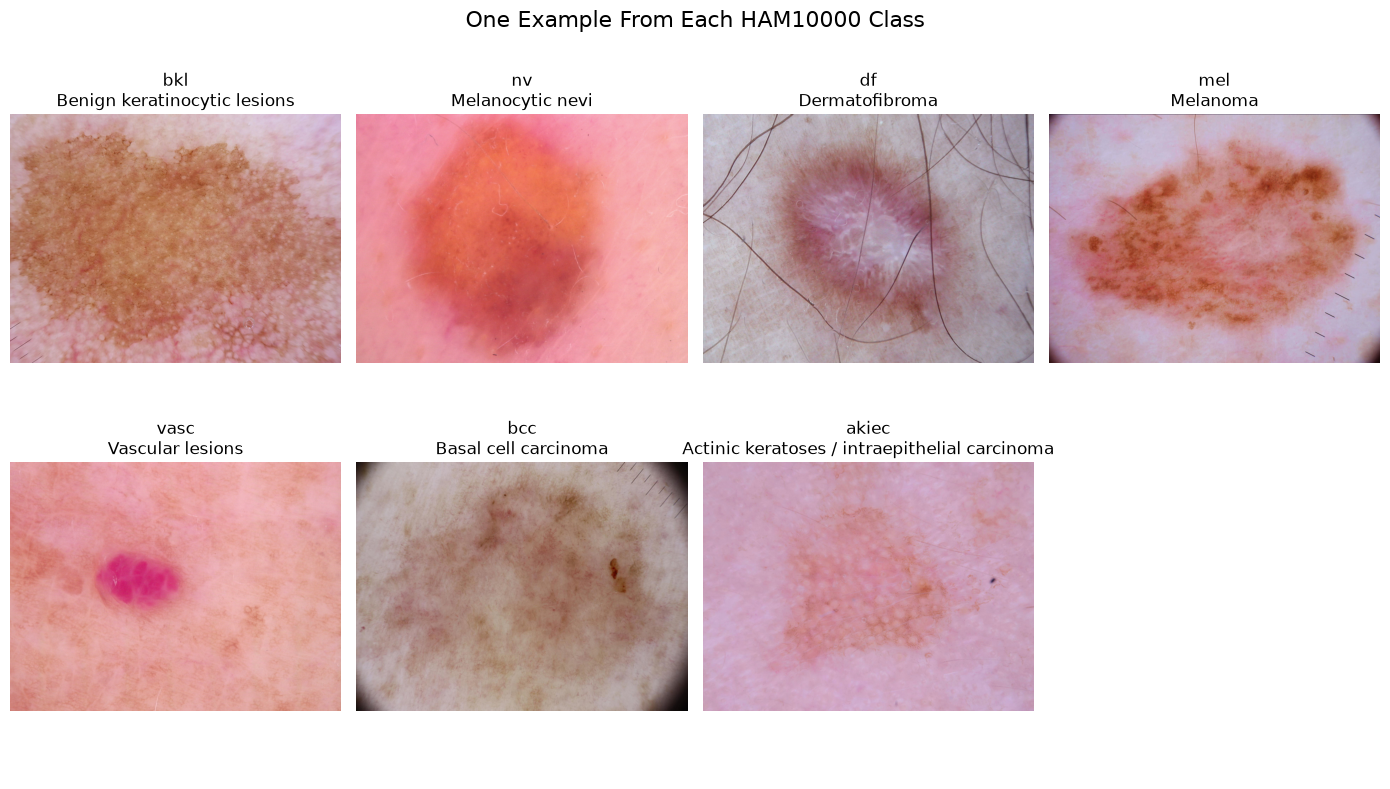

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

classes = df["dx"].unique()

for i, class_name in enumerate(classes):
    # Pick one random image from this class
    sample = df[df["dx"] == class_name].sample(
        1,
        random_state=42
    ).iloc[0]

    image_id = sample["image_id"]
    image_path = IMAGE_DIR / f"{image_id}.jpg"

    img = Image.open(image_path)

    axes[i].imshow(img)
    axes[i].set_title(
        f"{class_name}\n{label_names[class_name]}"
    )
    axes[i].axis("off")

# Hide the unused 8th subplot
axes[-1].axis("off")

plt.suptitle("One Example From Each HAM10000 Class", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
print("Total images:", len(df))
print("Unique lesions:", df["lesion_id"].nunique())
print("Images belonging to repeated lesions:",
      df["lesion_id"].duplicated(keep=False).sum())

Total images: 10015
Unique lesions: 7470
Images belonging to repeated lesions: 4501


In [18]:
lesion_counts = df["lesion_id"].value_counts()

print("Lesions with multiple images:",
      (lesion_counts > 1).sum())

print("Maximum images for one lesion:",
      lesion_counts.max())

Lesions with multiple images: 1956
Maximum images for one lesion: 6


In [19]:
lesion_label_counts = df.groupby("lesion_id")["dx"].nunique()

print("Lesions with multiple diagnoses:",
      (lesion_label_counts > 1).sum())

print("Maximum different diagnoses for one lesion:",
      lesion_label_counts.max())

Lesions with multiple diagnoses: 0
Maximum different diagnoses for one lesion: 1


In [20]:
lesion_class_counts = (
    df.groupby("dx")["lesion_id"]
      .nunique()
      .sort_values(ascending=False)
)

lesion_class_counts

dx
nv       5403
bkl       727
mel       614
bcc       327
akiec     228
vasc       98
df         73
Name: lesion_id, dtype: int64

In [21]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

df["split"] = None

for fold, (_, val_idx) in enumerate(
    sgkf.split(
        X=df,
        y=df["dx"],
        groups=df["lesion_id"]
    )
):
    df.loc[val_idx, "split"] = fold

print(df["split"].value_counts().sort_index())

split
0    1002
1    1002
2    1002
3    1002
4    1002
5    1001
6    1001
7    1001
8    1001
9    1001
Name: count, dtype: int64


In [22]:
df.loc[df["split"] == 0, "dataset_split"] = "test"
df.loc[df["split"] == 1, "dataset_split"] = "validation"
df.loc[df["split"].isin(range(2, 10)), "dataset_split"] = "train"

df["dataset_split"].value_counts()

dataset_split
train         8011
validation    1002
test          1002
Name: count, dtype: int64

In [23]:
split_lesions = {
    split: set(df.loc[df["dataset_split"] == split, "lesion_id"])
    for split in ["train", "validation", "test"]
}

print(
    "Train ∩ Validation:",
    len(split_lesions["train"] & split_lesions["validation"])
)

print(
    "Train ∩ Test:",
    len(split_lesions["train"] & split_lesions["test"])
)

print(
    "Validation ∩ Test:",
    len(split_lesions["validation"] & split_lesions["test"])
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [24]:
split_distribution = pd.crosstab(
    df["dx"],
    df["dataset_split"]
)

split_distribution

dataset_split,test,train,validation
dx,,,
akiec,32,262,33
bcc,51,411,52
bkl,110,879,110
df,12,92,11
mel,112,890,111
nv,671,5363,671
vasc,14,114,14


In [25]:
split_percentages = pd.crosstab(
    df["dx"],
    df["dataset_split"],
    normalize="columns"
) * 100

split_percentages.round(2)

dataset_split,test,train,validation
dx,,,
akiec,3.19,3.27,3.29
bcc,5.09,5.13,5.19
bkl,10.98,10.97,10.98
df,1.20,1.15,1.10
mel,11.18,11.11,11.08
nv,66.97,66.95,66.97
vasc,1.40,1.42,1.40


In [26]:
train_df = df[df["dataset_split"] == "train"].copy()
val_df = df[df["dataset_split"] == "validation"].copy()
test_df = df[df["dataset_split"] == "test"].copy()

train_df.to_csv(
    PROJECT_ROOT / "data" / "processed" / "train.csv",
    index=False
)

val_df.to_csv(
    PROJECT_ROOT / "data" / "processed" / "validation.csv",
    index=False
)

test_df.to_csv(
    PROJECT_ROOT / "data" / "processed" / "test.csv",
    index=False
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 8011
Validation: 1002
Test: 1002
